In [1]:
from google.colab import files

uploaded = files.upload()

Saving Session_data.xlsx to Session_data.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("Session_data.xlsx")

df.head()

,Session,CCS,Arrival,Departure,Stay (min),Energy (Wh),Pmax (W),Preq_max (W),"Controlled session (0=False, 1=True)",TotalCapacity,BulkCapacity,SOC arrival,SOC departure,Energy capacity (Wh)
0,278,CCS1,2022-08-11 23:33:00,2022-08-11 23:37:00,5,9632.0,168393,192417,1,79140,63312,25.999495,35.999495,91504.000000
1,897,CCS1,2023-04-22 09:46:00,2023-04-22 09:50:00,5,3993.0,87201,192417,1,75200,60160,45.000000,49.000000,94833.750000
2,958,CCS1,2023-05-18 13:24:00,2023-05-18 13:28:00,5,4567.0,79593,252297,1,10000,8000,21.000000,27.000000,72310.833333
3,1046,CCS1,2023-06-18 16:14:00,2023-06-18 16:18:00,5,5591.0,120198,232965,1,10000,8000,46.990000,55.000000,66310.237203
4,1095,CCS1,2023-06-28 14:39:00,2023-06-28 14:43:00,5,6400.0,128517,353265,1,10000,8000,45.000000,54.000000,67555.555556


In [3]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Rows and Columns: (1878, 14)

Column Names:
['Session', 'CCS', 'Arrival', 'Departure', 'Stay (min)', 'Energy (Wh)', 'Pmax (W)', 'Preq_max (W)', 'Controlled session (0=False, 1=True)', 'TotalCapacity', 'BulkCapacity', 'SOC arrival', 'SOC departure', 'Energy capacity (Wh)']

Data Types:
Session                                          int64
CCS                                             object
Arrival                                 datetime64[ns]
Departure                               datetime64[ns]
Stay (min)                                       int64
Energy (Wh)                                    float64
Pmax (W)                                         int64
Preq_max (W)                                     int64
Controlled session (0=False, 1=True)             int64
TotalCapacity                                    int64
BulkCapacity                                     int64
SOC arrival                                    float64
SOC departure                                  float64

#2. Basic data-quality check

In [4]:
print("Duplicate Rows:", df.duplicated().sum())

print("\nDate Range:")
print("First session:", df["Arrival"].min())
print("Last session:", df["Arrival"].max())

print("\nBasic Statistics:")
print(df[["Stay (min)", "Energy (Wh)", "Pmax (W)", "SOC arrival", "SOC departure"]].describe())

Duplicate Rows: 0

Date Range:
First session: 2022-04-12 19:27:00
Last session: 2023-07-04 23:03:00

Basic Statistics:
        Stay (min)    Energy (Wh)       Pmax (W)  SOC arrival  SOC departure
count  1878.000000    1878.000000    1878.000000  1878.000000    1878.000000
mean     32.915868   32184.204247  102494.722045    33.674322      79.140417
std      17.580331   19407.367487   41905.368685    19.147568      18.404431
min       5.000000    1165.000000   13986.000000     0.000000      12.000000
25%      20.000000   17979.750000   65060.250000    19.000000      70.000000
50%      30.000000   29367.000000   97654.500000    31.000000      82.990000
75%      42.000000   43285.250000  145188.000000    46.000000      93.000000
max     144.000000  268863.000000  174846.000000    98.000000     100.000000


#3.Make our column names easier


In [5]:
df = df.rename(columns={
    "Stay (min)": "stay_min",
    "Energy (Wh)": "energy_wh",
    "Pmax (W)": "pmax_w",
    "Preq_max (W)": "preq_max_w",
    "Controlled session (0=False, 1=True)": "controlled",
    "SOC arrival": "soc_arrival",
    "SOC departure": "soc_departure",
    "Energy capacity (Wh)": "energy_capacity_wh"
})

df.head()

,Session,CCS,Arrival,Departure,stay_min,energy_wh,pmax_w,preq_max_w,controlled,TotalCapacity,BulkCapacity,soc_arrival,soc_departure,energy_capacity_wh
0,278,CCS1,2022-08-11 23:33:00,2022-08-11 23:37:00,5,9632.0,168393,192417,1,79140,63312,25.999495,35.999495,91504.000000
1,897,CCS1,2023-04-22 09:46:00,2023-04-22 09:50:00,5,3993.0,87201,192417,1,75200,60160,45.000000,49.000000,94833.750000
2,958,CCS1,2023-05-18 13:24:00,2023-05-18 13:28:00,5,4567.0,79593,252297,1,10000,8000,21.000000,27.000000,72310.833333
3,1046,CCS1,2023-06-18 16:14:00,2023-06-18 16:18:00,5,5591.0,120198,232965,1,10000,8000,46.990000,55.000000,66310.237203
4,1095,CCS1,2023-06-28 14:39:00,2023-06-28 14:43:00,5,6400.0,128517,353265,1,10000,8000,45.000000,54.000000,67555.555556


#4. Feature Engineering

In [6]:
df["hour"] = df["Arrival"].dt.hour
df["day"] = df["Arrival"].dt.day_name()
df["month"] = df["Arrival"].dt.to_period("M").astype(str)

df["day_type"] = np.where(
    df["Arrival"].dt.dayofweek < 5,
    "Weekday",
    "Weekend"
)

df.head()

,Session,CCS,Arrival,Departure,stay_min,energy_wh,pmax_w,preq_max_w,controlled,TotalCapacity,BulkCapacity,soc_arrival,soc_departure,energy_capacity_wh,hour,day,month,day_type
0,278,CCS1,2022-08-11 23:33:00,2022-08-11 23:37:00,5,9632.0,168393,192417,1,79140,63312,25.999495,35.999495,91504.000000,23,Thursday,2022-08,Weekday
1,897,CCS1,2023-04-22 09:46:00,2023-04-22 09:50:00,5,3993.0,87201,192417,1,75200,60160,45.000000,49.000000,94833.750000,9,Saturday,2023-04,Weekend
2,958,CCS1,2023-05-18 13:24:00,2023-05-18 13:28:00,5,4567.0,79593,252297,1,10000,8000,21.000000,27.000000,72310.833333,13,Thursday,2023-05,Weekday
3,1046,CCS1,2023-06-18 16:14:00,2023-06-18 16:18:00,5,5591.0,120198,232965,1,10000,8000,46.990000,55.000000,66310.237203,16,Sunday,2023-06,Weekend
4,1095,CCS1,2023-06-28 14:39:00,2023-06-28 14:43:00,5,6400.0,128517,353265,1,10000,8000,45.000000,54.000000,67555.555556,14,Wednesday,2023-06,Weekday


In [7]:
print(df[["Arrival", "hour", "day", "month", "day_type"]].head(10))

              Arrival  hour        day    month day_type
0 2022-08-11 23:33:00    23   Thursday  2022-08  Weekday
1 2023-04-22 09:46:00     9   Saturday  2023-04  Weekend
2 2023-05-18 13:24:00    13   Thursday  2023-05  Weekday
3 2023-06-18 16:14:00    16     Sunday  2023-06  Weekend
4 2023-06-28 14:39:00    14  Wednesday  2023-06  Weekday
5 2022-10-14 11:48:00    11     Friday  2022-10  Weekday
6 2022-10-16 11:56:00    11     Sunday  2022-10  Weekend
7 2022-11-09 11:29:00    11  Wednesday  2022-11  Weekday
8 2023-03-30 14:54:00    14   Thursday  2023-03  Weekday
9 2022-04-16 11:19:00    11   Saturday  2022-04  Weekend


In [8]:
print(df["day_type"].value_counts())

print("\nSessions by hour:")
print(df["hour"].value_counts().sort_index())

day_type
Weekday    1384
Weekend     494
Name: count, dtype: int64

Sessions by hour:
hour
0      12
1      16
2       7
3       5
4       4
5      13
6      30
7      35
8      65
9     105
10     99
11    141
12    133
13    124
14    128
15    153
16    145
17    149
18    156
19    114
20     79
21     90
22     48
23     27
Name: count, dtype: int64


#Create SQLite database

In [9]:
import sqlite3

conn = sqlite3.connect("ev_charging.db")

df.to_sql("charging_sessions",conn,if_exists="replace",index=False)

print("Data loaded into SQLite successfully!")

Data loaded into SQLite successfully!


In [10]:
query = """
SELECT COUNT(*) AS total_sessions
FROM charging_sessions;
"""

result = pd.read_sql_query(query, conn)

result

,total_sessions
0,1878


#calculate total energy delivered and average energy per session.

In [11]:
query = """
SELECT
    SUM(energy_wh) AS total_energy_wh,
    AVG(energy_wh) AS avg_energy_wh
FROM charging_sessions;
"""

result = pd.read_sql_query(query, conn)

result

,total_energy_wh,avg_energy_wh
0,6.044194e+07,32184.204247


#Average Charging Duration

In [12]:
query = """
SELECT
    AVG(stay_min) AS avg_stay_min,
    MIN(stay_min) AS min_stay_min,
    MAX(stay_min) AS max_stay_min
FROM charging_sessions;
"""

result = pd.read_sql_query(query, conn)

result

,avg_stay_min,min_stay_min,max_stay_min
0,32.915868,5,144


#Busiest Charging Hours

In [13]:
query = """
SELECT
    hour,
    COUNT(*) AS sessions
FROM charging_sessions
GROUP BY hour
ORDER BY sessions DESC;
"""

result = pd.read_sql_query(query, conn)

result

,hour,sessions
0,18,156
1,15,153
2,17,149
3,16,145
4,11,141
5,12,133
6,14,128
7,13,124
8,19,114
9,9,105


# visualization — Sessions by Hour

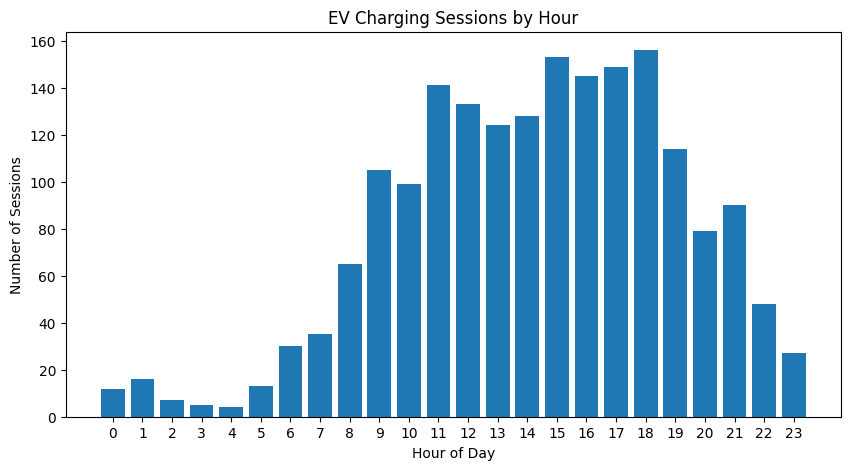

In [14]:
# Sessions by Hour

hourly_sessions = df.groupby("hour").size()

plt.figure(figsize=(10, 5))

plt.bar(hourly_sessions.index, hourly_sessions.values)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Sessions")
plt.title("EV Charging Sessions by Hour")

plt.xticks(range(24))

plt.show()

In [15]:
peak_hour = hourly_sessions.idxmax()
peak_sessions = hourly_sessions.max()

print("Peak Charging Hour:", peak_hour)
print("Sessions at Peak Hour:", peak_sessions)

Peak Charging Hour: 18
Sessions at Peak Hour: 156


In [16]:
# Monthly Charging Trend
monthly_sessions = df.groupby("month").size()

print(monthly_sessions)

month
2022-04    117
2022-05    101
2022-06    166
2022-07     66
2022-08     35
2022-10    220
2022-11    275
2022-12     12
2023-02     94
2023-03    239
2023-04    172
2023-05    152
2023-06    198
2023-07     31
dtype: int64


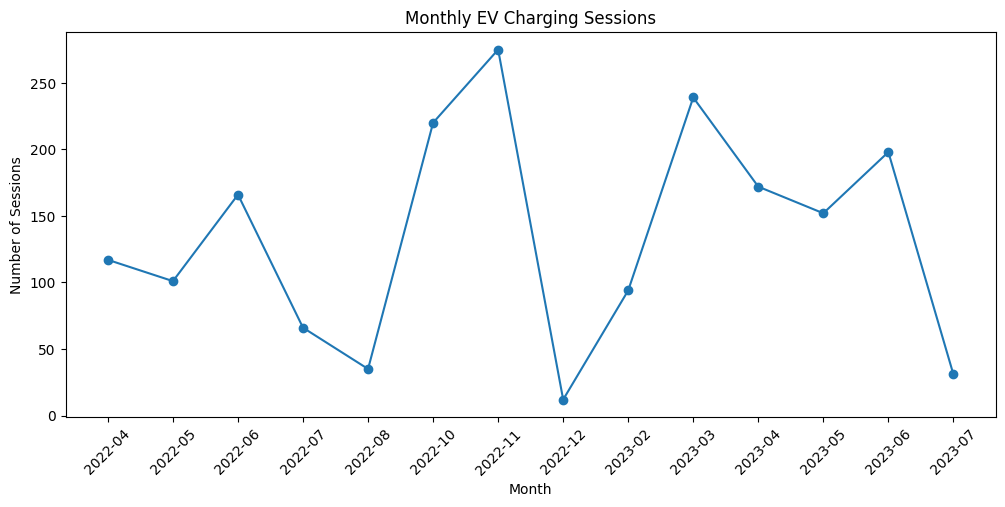

In [18]:
#Monthly Trend

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sessions.index,
    monthly_sessions.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Number of Sessions")
plt.title("Monthly EV Charging Sessions")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Weekday vs Weekend
# We already know:
                    # Weekday → 1,384 sessions
                    # Weekend → 494 sessions

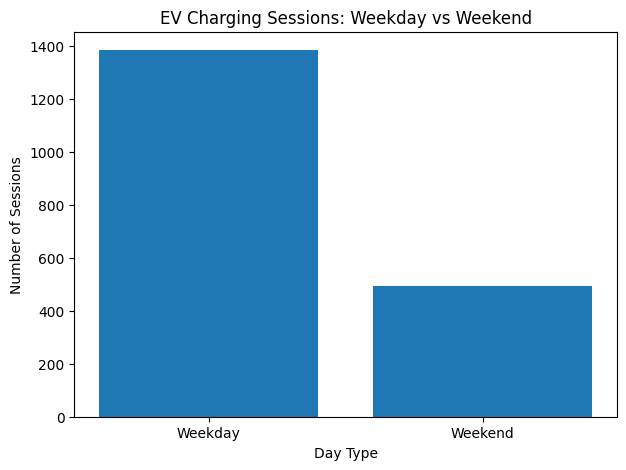

In [19]:
day_type_sessions = df["day_type"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(day_type_sessions.index, day_type_sessions.values)

plt.xlabel("Day Type")
plt.ylabel("Number of Sessions")
plt.title("EV Charging Sessions: Weekday vs Weekend")

plt.show()

#5. Energy Analysis

In [20]:
energy_kpis = {
    "Total Energy Delivered (kWh)": df["energy_wh"].sum() / 1000,
    "Average Energy per Session (kWh)": df["energy_wh"].mean() / 1000,
    "Minimum Energy per Session (kWh)": df["energy_wh"].min() / 1000,
    "Maximum Energy per Session (kWh)": df["energy_wh"].max() / 1000
}

energy_kpis

{'Total Energy Delivered (kWh)': np.float64(60441.935575),
 'Average Energy per Session (kWh)': np.float64(32.184204246538876),
 'Minimum Energy per Session (kWh)': 1.165,
 'Maximum Energy per Session (kWh)': 268.863}

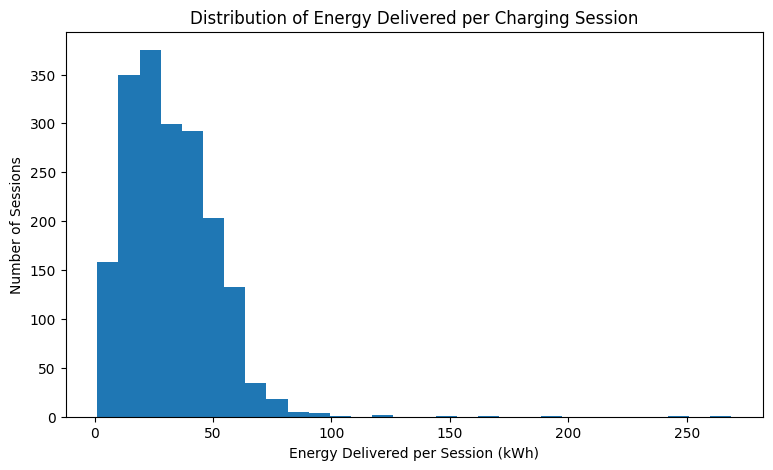

In [21]:
plt.figure(figsize=(9, 5))

plt.hist(df["energy_wh"] / 1000, bins=30)

plt.xlabel("Energy Delivered per Session (kWh)")
plt.ylabel("Number of Sessions")
plt.title("Distribution of Energy Delivered per Charging Session")

plt.show()

In [22]:
#Weekday vs Weekend Energy
energy_by_day_type = df.groupby("day_type")["energy_wh"].agg(
    ["count", "sum", "mean"]
)

energy_by_day_type["total_energy_kwh"] = (
    energy_by_day_type["sum"] / 1000
)

energy_by_day_type["avg_energy_kwh"] = (
    energy_by_day_type["mean"] / 1000
)

energy_by_day_type

,count,sum,mean,total_energy_kwh,avg_energy_kwh
day_type,,,,,
Weekday,1384,4.490780e+07,32447.829335,44907.795800,32.447829
Weekend,494,1.553414e+07,31445.627075,15534.139775,31.445627


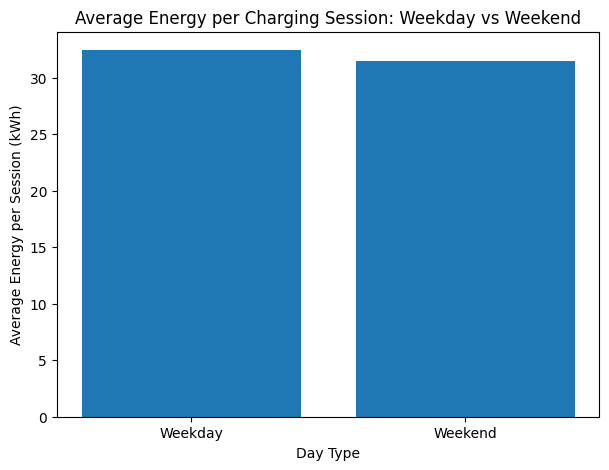

In [23]:
avg_energy_day_type = df.groupby("day_type")["energy_wh"].mean() / 1000

plt.figure(figsize=(7, 5))

plt.bar(
    avg_energy_day_type.index,
    avg_energy_day_type.values
)

plt.xlabel("Day Type")
plt.ylabel("Average Energy per Session (kWh)")
plt.title("Average Energy per Charging Session: Weekday vs Weekend")

plt.show()

In [25]:
# session categories
df["session_category"] = np.where(
    df["stay_min"] <= 20,
    "Short",
    np.where(
        df["stay_min"] <= 40,
        "Medium",
        "Long"
    )
)

df["session_category"].value_counts()

,count
session_category,
Medium,869
Long,526
Short,483


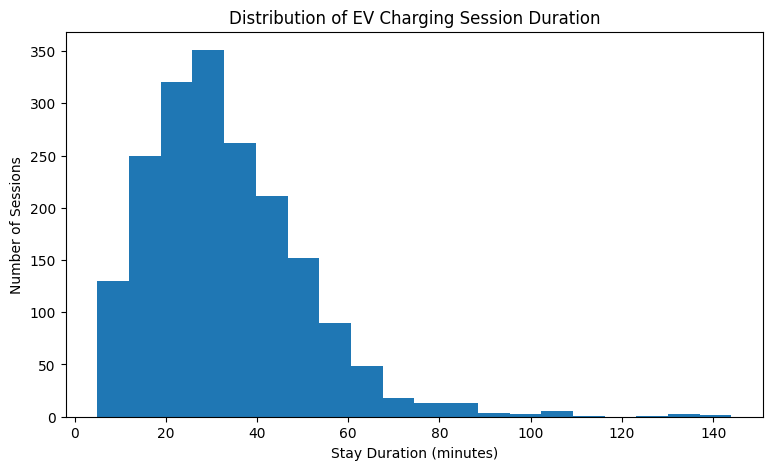

In [26]:
plt.figure(figsize=(9, 5))

plt.hist(df["stay_min"], bins=20)

plt.xlabel("Stay Duration (minutes)")
plt.ylabel("Number of Sessions")
plt.title("Distribution of EV Charging Session Duration")

plt.show()

In [ ]:
# Connector Analysis
# Our dataset has a CCS column, so let's see whether there are different charging connectors and how frequently they are used

In [27]:
ccs_sessions = df["CCS"].value_counts()

print(ccs_sessions)

CCS
CCS1    1129
CCS2     749
Name: count, dtype: int64


In [28]:
ccs_energy = df.groupby("CCS")["energy_wh"].agg(["count", "sum", "mean"])

ccs_energy["total_energy_kwh"] = ccs_energy["sum"] / 1000
ccs_energy["avg_energy_kwh"] = ccs_energy["mean"] / 1000

ccs_energy

,count,sum,mean,total_energy_kwh,avg_energy_kwh
CCS,,,,,
CCS1,1129,3.651359e+07,32341.528875,36513.586100,32.341529
CCS2,749,2.392835e+07,31947.062049,23928.349475,31.947062


In [29]:
power_kpi = {
    "Average Max Charging Power (kW)": df["pmax_w"].mean() / 1000,
    "Minimum Max Charging Power (kW)": df["pmax_w"].min() / 1000,
    "Maximum Max Charging Power (kW)": df["pmax_w"].max() / 1000
}

power_kpi

{'Average Max Charging Power (kW)': np.float64(102.49472204472843),
 'Minimum Max Charging Power (kW)': 13.986,
 'Maximum Max Charging Power (kW)': 174.846}

In [30]:
import os

os.makedirs("visualizations", exist_ok=True)

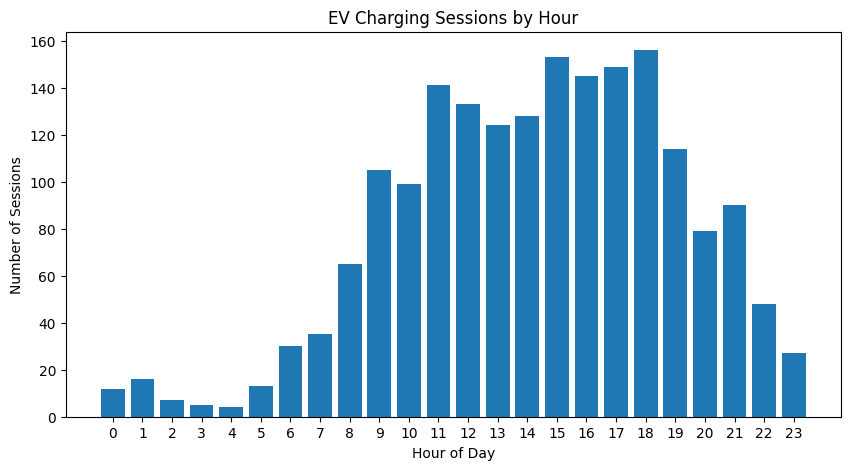

In [32]:
# 1. Sessions by hour
plt.figure(figsize=(10, 5))

plt.bar(hourly_sessions.index, hourly_sessions.values)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Sessions")
plt.title("EV Charging Sessions by Hour")
plt.xticks(range(24))

plt.savefig("visualizations/sessions_by_hour.png",
            dpi=300, bbox_inches="tight")

plt.show()

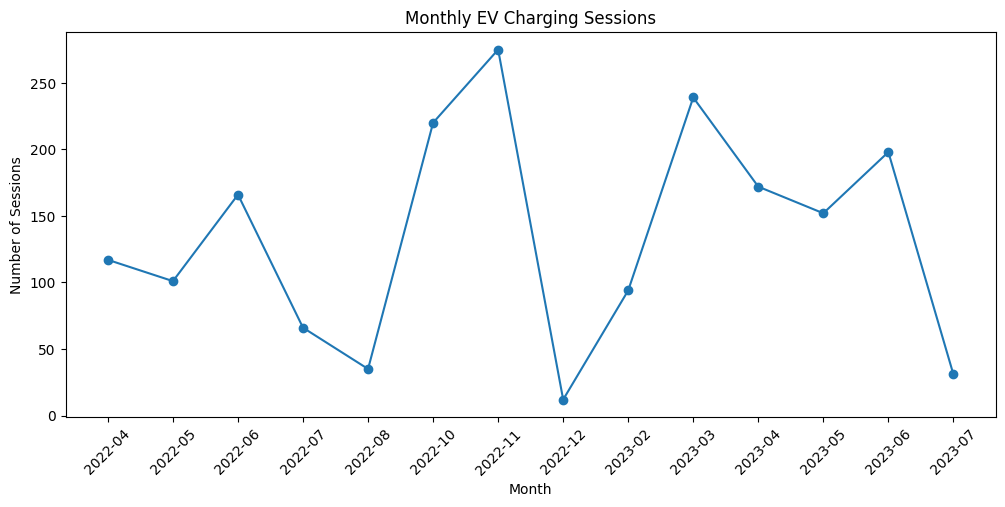

In [33]:
# 2. Monthly trend
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sessions.index,
    monthly_sessions.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Number of Sessions")
plt.title("Monthly EV Charging Sessions")
plt.xticks(rotation=45)

plt.savefig("visualizations/monthly_sessions.png",
            dpi=300, bbox_inches="tight")

plt.show()

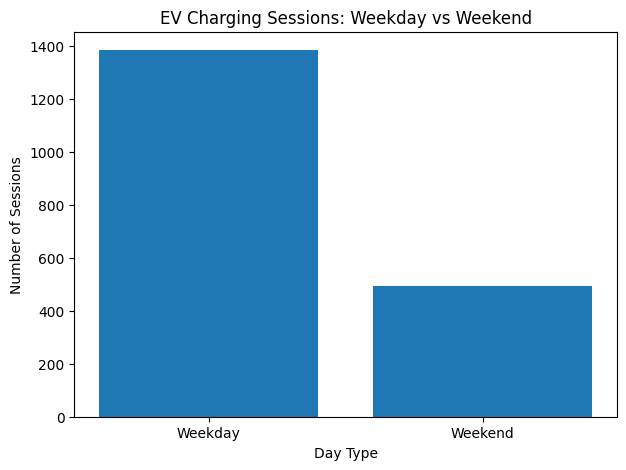

In [34]:
# 3. Weekday vs Weekend
plt.figure(figsize=(7, 5))

plt.bar(day_type_sessions.index, day_type_sessions.values)

plt.xlabel("Day Type")
plt.ylabel("Number of Sessions")
plt.title("EV Charging Sessions: Weekday vs Weekend")

plt.savefig("visualizations/weekday_vs_weekend.png",
            dpi=300, bbox_inches="tight")

plt.show()

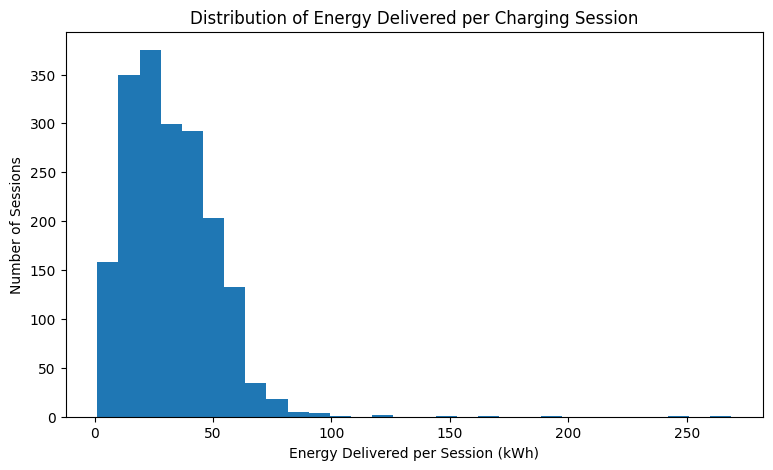

In [35]:
# 4. Energy distribution
plt.figure(figsize=(9, 5))

plt.hist(df["energy_wh"] / 1000, bins=30)

plt.xlabel("Energy Delivered per Session (kWh)")
plt.ylabel("Number of Sessions")
plt.title("Distribution of Energy Delivered per Charging Session")

plt.savefig("visualizations/energy_distribution.png",
            dpi=300, bbox_inches="tight")

plt.show()

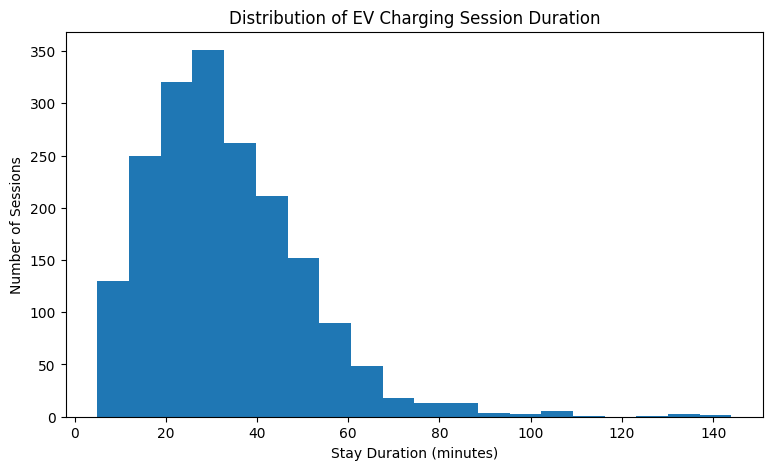

In [36]:
# 5. Session duration
plt.figure(figsize=(9, 5))

plt.hist(df["stay_min"], bins=20)

plt.xlabel("Stay Duration (minutes)")
plt.ylabel("Number of Sessions")
plt.title("Distribution of EV Charging Session Duration")

plt.savefig("visualizations/session_duration_distribution.png",
            dpi=300, bbox_inches="tight")

plt.show()

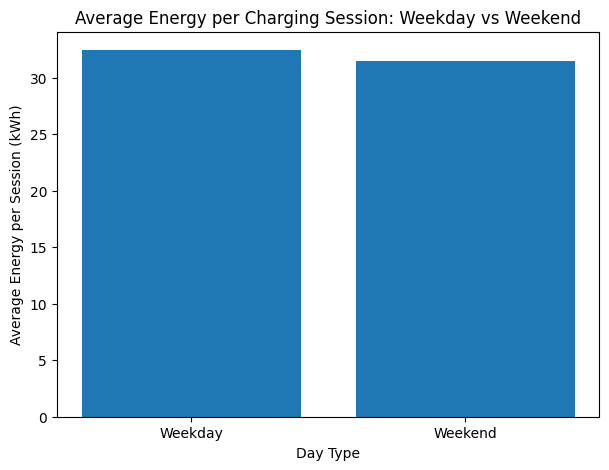

In [37]:
# 6. Average energy — weekday vs weekend
plt.figure(figsize=(7, 5))

plt.bar(
    avg_energy_day_type.index,
    avg_energy_day_type.values
)

plt.xlabel("Day Type")
plt.ylabel("Average Energy per Session (kWh)")
plt.title("Average Energy per Charging Session: Weekday vs Weekend")

plt.savefig("visualizations/avg_energy_day_type.png",
            dpi=300, bbox_inches="tight")

plt.show()

In [38]:
import os

os.makedirs("sql", exist_ok=True)

In [39]:
%%writefile sql/analysis.sql

-- ============================================================
-- EV Charging Operations & Revenue Analytics
-- SQL Analysis
-- ============================================================

-- 1. Total number of charging sessions
SELECT
    COUNT(*) AS total_sessions
FROM charging_sessions;


-- 2. Total energy delivered and average energy per session
SELECT
    SUM(energy_wh) AS total_energy_wh,
    AVG(energy_wh) AS avg_energy_wh
FROM charging_sessions;


-- 3. Charging session duration statistics
SELECT
    AVG(stay_min) AS avg_stay_min,
    MIN(stay_min) AS min_stay_min,
    MAX(stay_min) AS max_stay_min
FROM charging_sessions;


-- 4. Charging demand by hour
SELECT
    hour,
    COUNT(*) AS sessions
FROM charging_sessions
GROUP BY hour
ORDER BY sessions DESC;


-- 5. Charging sessions by day type
SELECT
    day_type,
    COUNT(*) AS sessions
FROM charging_sessions
GROUP BY day_type
ORDER BY sessions DESC;


-- 6. Energy delivered by day type
SELECT
    day_type,
    COUNT(*) AS sessions,
    SUM(energy_wh) / 1000.0 AS total_energy_kwh,
    AVG(energy_wh) / 1000.0 AS avg_energy_kwh
FROM charging_sessions
GROUP BY day_type
ORDER BY total_energy_kwh DESC;


-- 7. Connector utilization
SELECT
    CCS,
    COUNT(*) AS sessions,
    SUM(energy_wh) / 1000.0 AS total_energy_kwh,
    AVG(energy_wh) / 1000.0 AS avg_energy_kwh
FROM charging_sessions
GROUP BY CCS
ORDER BY sessions DESC;


-- 8. Monthly charging activity
SELECT
    month,
    COUNT(*) AS sessions
FROM charging_sessions
GROUP BY month
ORDER BY month;

Writing sql/analysis.sql


In [40]:
%%writefile README.md

# EV Charging Operations & Revenue Analytics

## Project Overview

This project analyzes EV charging session data to understand charging demand, energy delivery, session duration, connector usage, and operational patterns.

The analysis uses a real EV charging session dataset containing 1,878 charging sessions recorded between April 2022 and July 2023.

The goal is to transform raw charging-session data into practical operational insights using Python, Pandas, NumPy, Matplotlib, and SQL.

---

## Business Questions

The analysis focuses on the following questions:

1. How many charging sessions were recorded?
2. How much energy was delivered?
3. When is charging demand highest?
4. How does charging activity vary over time?
5. Are weekdays busier than weekends?
6. How much energy is delivered per session?
7. How long do charging sessions typically last?
8. Which charging connector is used most frequently?
9. What operational patterns can support charger planning?

---

## Dataset

The dataset contains 1,878 charging sessions and 14 original columns, including:

- Session
- CCS
- Arrival
- Departure
- Stay (min)
- Energy (Wh)
- Pmax (W)
- Preq_max (W)
- Controlled session
- TotalCapacity
- BulkCapacity
- SOC arrival
- SOC departure
- Energy capacity (Wh)

### Data Quality

- Rows: 1,878
- Columns: 14
- Missing values: 0
- Duplicate rows: 0
- First recorded session: April 12, 2022
- Last recorded session: July 4, 2023

---

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- SQL
- SQLite
- Google Colab
- Excel

---

## Data Preparation

The analysis included:

- Data quality checks
- Duplicate detection
- Missing-value validation
- Datetime feature extraction
- Hour extraction
- Month extraction
- Weekday/weekend classification
- Session-duration categorization
- Energy unit conversion from Wh to kWh

---

## SQL Analysis

The dataset was loaded into a SQLite database and analyzed using SQL.

Key SQL operations included:

- COUNT
- SUM
- AVG
- MIN
- MAX
- GROUP BY
- ORDER BY

The SQL queries are available in:

`sql/analysis.sql`

---

## Key KPIs

| KPI | Result |
|---|---:|
| Total charging sessions | 1,878 |
| Total energy delivered | 60,441.94 kWh |
| Average energy per session | 32.18 kWh |
| Average session duration | 32.92 minutes |
| Peak charging hour | 18:00 |
| Sessions at peak hour | 156 |
| Weekday sessions | 1,384 |
| Weekend sessions | 494 |
| Most-used connector | CCS1 |
| CCS1 sessions | 1,129 |
| Average maximum charging power | 102.49 kW |

---

## Key Insights

### 1. Peak Charging Demand

18:00 was the busiest recorded charging hour with 156 sessions. Charging activity remained relatively strong throughout the afternoon and early evening.

### 2. Weekday-Heavy Charging Activity

73.7% of recorded sessions occurred on weekdays, compared with 26.3% on weekends.

### 3. Energy Throughput

The dataset contains approximately 60,441.94 kWh of delivered energy across 1,878 charging sessions.

The average session delivered approximately 32.18 kWh.

### 4. Session Duration

The average session duration was approximately 32.92 minutes.

Medium-duration sessions were the largest derived category, with 869 sessions representing approximately 46.3% of all sessions.

### 5. Connector Usage

CCS1 accounted for 1,129 sessions, or approximately 60.1% of all recorded sessions.

Average energy per session was similar between CCS1 and CCS2.

### 6. Energy Distribution

Most sessions delivered moderate amounts of energy, while a smaller number of high-energy sessions created a long right tail in the distribution.

---

## Visualizations

The project includes the following visualizations:

- Charging Sessions by Hour
- Monthly Charging Sessions
- Weekday vs Weekend Sessions
- Energy Delivered Distribution
- Session Duration Distribution
- Average Energy per Session by Day Type

Visualizations are stored in the `visualizations/` directory.

---

## Project Structure

```text
EV_Charging_Analytics/
│
├── data/
│   └── Session_data.xlsx
│
├── notebooks/
│   └── ev_charging_analysis.ipynb
│
├── sql/
│   └── analysis.sql
│
├── visualizations/
│   ├── sessions_by_hour.png
│   ├── monthly_sessions.png
│   ├── weekday_vs_weekend.png
│   ├── energy_distribution.png
│   ├── session_duration_distribution.png
│   └── avg_energy_day_type.png
│
└── README.md

Writing README.md


In [41]:
import os
import shutil

# Create final project folders
os.makedirs("EV_Charging_Analytics/data", exist_ok=True)
os.makedirs("EV_Charging_Analytics/sql", exist_ok=True)
os.makedirs("EV_Charging_Analytics/visualizations", exist_ok=True)

# Copy dataset
shutil.copy(
    "Session_data.xlsx",
    "EV_Charging_Analytics/data/Session_data.xlsx"
)

# Copy SQL and README
shutil.copy(
    "sql/analysis.sql",
    "EV_Charging_Analytics/sql/analysis.sql"
)

shutil.copy(
    "README.md",
    "EV_Charging_Analytics/README.md"
)

# Copy visualizations
for file in os.listdir("visualizations"):
    shutil.copy(
        os.path.join("visualizations", file),
        os.path.join("EV_Charging_Analytics/visualizations", file)
    )

print("Project package created successfully!")

Project package created successfully!


In [42]:
import os

for root, dirs, files in os.walk("EV_Charging_Analytics"):
    level = root.replace("EV_Charging_Analytics", "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

EV_Charging_Analytics/
    README.md
    visualizations/
        sessions_by_hour.png
        avg_energy_day_type.png
        monthly_sessions.png
        session_duration_distribution.png
        weekday_vs_weekend.png
        energy_distribution.png
    sql/
        analysis.sql
    data/
        Session_data.xlsx


In [43]:
import shutil
from google.colab import files

shutil.make_archive(
    "EV_Charging_Analytics",
    "zip",
    "EV_Charging_Analytics"
)

files.download("EV_Charging_Analytics.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
import os
import shutil

os.makedirs("EV_Charging_Analytics/data", exist_ok=True)
os.makedirs("EV_Charging_Analytics/sql", exist_ok=True)
os.makedirs("EV_Charging_Analytics/visualizations", exist_ok=True)

shutil.copy("Session_data.xlsx",
            "EV_Charging_Analytics/data/Session_data.xlsx")

shutil.copy("sql/analysis.sql",
            "EV_Charging_Analytics/sql/analysis.sql")

shutil.copy("README.md",
            "EV_Charging_Analytics/README.md")

for file in os.listdir("visualizations"):
    shutil.copy(
        os.path.join("visualizations", file),
        os.path.join("EV_Charging_Analytics/visualizations", file)
    )

print("Project package created successfully!")

Project package created successfully!


In [45]:
import os

for root, dirs, files in os.walk("EV_Charging_Analytics"):
    print(root, files)

EV_Charging_Analytics ['README.md']
EV_Charging_Analytics/visualizations ['sessions_by_hour.png', 'avg_energy_day_type.png', 'monthly_sessions.png', 'session_duration_distribution.png', 'weekday_vs_weekend.png', 'energy_distribution.png']
EV_Charging_Analytics/sql ['analysis.sql']
EV_Charging_Analytics/data ['Session_data.xlsx']


In [46]:
import shutil
from google.colab import files

shutil.make_archive(
    "EV_Charging_Analytics",
    "zip",
    "EV_Charging_Analytics"
)

files.download("EV_Charging_Analytics.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>